# NIF Laser sampling

<a href="[text](https://creativecommons.org/licenses/by-nc/4.0/)">LaserIllumination</a> © 2025 by <a href="https://creativecommons.org">M. Cotelo, A. Lorca (Universidad Politécnica de Madrid)</a> is licensed under <a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International</a><img src="https://mirrors.creativecommons.org/presskit/icons/cc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/by.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/nc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/sa.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;">


Authors:
- Manuel Cotelo Ferreiro (<manuel.cotelo@upm.es>) (Instituto de Fusión Nuclear Guillermo Velarde, Universidad Politécnica de Madrid)
- Alberto Lorca (<alberto.lorca@alumnos.upm.es>) (Universidad Politécnica de Madrid)

In [67]:
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import uniform
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd
import pyvista as pv
 #!pip install trame
from scipy.stats import norm
import scipy.stats as stats



## Chamber and Target Parameters

In [68]:
# Radio del círculo INSCRITO en la ventana 40x40 cm
R_INSCRITO = 0.20    # metros (20 cm)
R_TARGET = 0.001     # metros (1 mm)
R_CAMARA = 5.0       # metros (ventana -> blanco)
VENTANA_SIZE = 0.80


## Support functions

### Sphere parameters

In [69]:
def sph_to_cart(r, theta, phi):
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    return np.array([x, y, z])

def cart_to_sph(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(z / r)
    phi = np.pi + np.arctan2(y, x)
    return np.array([r, theta, phi])

### Spherical function plotter

In [70]:
def plot_spherical_function(theta, phi, f, name='f', title="Spherical Function"):
  f_flat = f.ravel()

  xs, ys, zs = sph_to_cart(1.0, theta, phi)
  points = np.column_stack((xs.ravel(), ys.ravel(), zs.ravel()))
  f_flat = f.ravel()

  cloud = pv.PolyData(points)
  cloud[name] = f_flat

  plotter = pv.Plotter()
  plotter.add_mesh(cloud, render_points_as_spheres=True, point_size=10, scalars=name, cmap='plasma')
  plotter.add_scalar_bar(title=name, vertical=True)

  return plotter

### Plotter of sectors given theta and phi

In [71]:
def plot_spherical_sectors( theta, phi, fs, name='func', title="Spherical Sectors" ):

  func = sp.interpolate.RegularGridInterpolator( (theta, phi), fs, method='nearest', bounds_error=False, fill_value=0.0 )

  sphere = pv.Sphere( theta_resolution=100, phi_resolution=100 )
  r, ts, ps = cart_to_sph( sphere.points[:,0], sphere.points[:,1], sphere.points[:,2] )
  sphere['Data'] = func( ( ts, ps, ) )

  plotter = pv.Plotter()
  plotter.add_mesh(sphere, scalar_bar_args={'title': 'Z Position'})
  
  return plotter


## Sample of random laser points in a 2D window

In [72]:
def sample_window( t1, t2, l1=1., l2=1., center=np.array([ 0., 0., 0., ]), num_points=1000, dist = lambda num_points: sp.stats.uniform.rvs( loc=-1.0, scale=2.0, size=( num_points, 2, ) ), ):
  # sample distribution 
  sample = np.zeros( (num_points, 2,) )
  k = 0
  while k < num_points:
    s = dist(1)
    if np.abs(s[0,0]) <= 1.0 and np.abs(s[0,1]) <= 1.0:
      sample[k,:] = s[0,:]
      k += 1
  # map to the window
  v1 = 0.5 * l1 * t1 / np.linalg.norm( t1 )
  v2 = 0.5 * l2 * t2 / np.linalg.norm( t2 )
  return center + sample[:,0,None] * v1 + sample[:,1,None] * v2

In [73]:

t1 = np.array([ 0., 1., 0., ]) # ey
t2 = np.array([ 0., 0., 1., ]) # ez

xs = sample_window( t1, t2, l1=2., l2=2., center=np.array([ 0., 0., 0., ]), num_points=1000, )

focus = np.array([ 1., 0., 0., ])
us = focus - xs
us = us / np.linalg.norm( us, axis=1 )[:,None]

print(xs.shape)

(1000, 3)


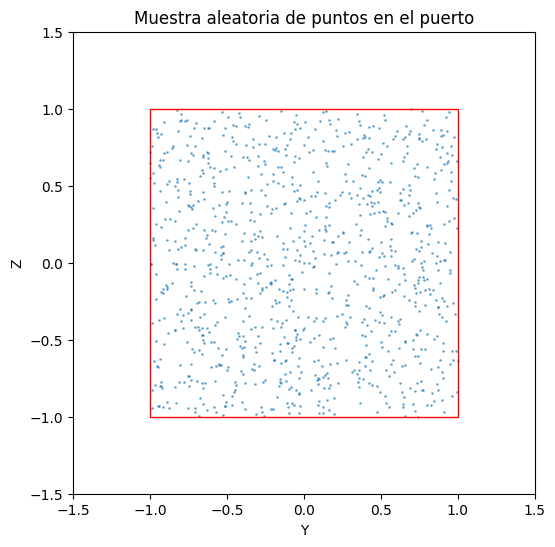

In [74]:
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter( xs[:,1], xs[:,2], s=1, alpha=0.5 )

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

ax.set_title("Muestra aleatoria de puntos en el puerto")
ax.set_xlabel("Y")
ax.set_ylabel("Z")

rect = plt.Rectangle( (-1,-1), 2, 2, linewidth=1, edgecolor='r', facecolor='none' )
ax.add_patch(rect)

### Use of normal distribution in the sample of points

In [75]:
dist = lambda num_points: sp.stats.norm(loc=0.0, scale=0.5).rvs(size=(num_points, 2))
xs = sample_window( t1, t2, l1=2., l2=2., center=np.array([ 0., 0., 0., ]), num_points=10000, dist=dist )
print(xs.shape  )

(10000, 3)


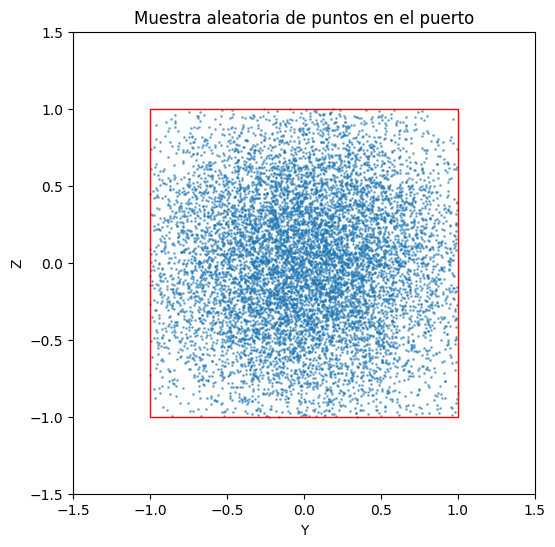

In [76]:
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter( xs[:,1], xs[:,2], s=1, alpha=0.5 )

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

ax.set_title("Muestra aleatoria de puntos en el puerto")
ax.set_xlabel("Y")
ax.set_ylabel("Z")

rect = plt.Rectangle( (-1,-1), 2, 2, linewidth=1, edgecolor='r', facecolor='none' )
ax.add_patch(rect)

# Define beam geometry and focal distances

### Define beams

In [77]:
def beam():
    # =====================================================
    # 1. Definición de puertos (Estructura base)
    # =====================================================
    def create_ports(theta, num, long_ref, root, color, energy, wavelength):
        list_long = long_ref + np.linspace(0., 2.*np.pi, num, endpoint=False)
        return [{
            'name': f'{root}J{i+1}',
            'LAT': theta,
            'LONG': long,
            'color': color,
            'energia': energy,
            'longonda': wavelength,
        } for i, long in enumerate(list_long)]

    ports = []
    # Hemisferio Norte
    ports += create_ports(np.deg2rad(23.5), 4, 0.,           'NP1', 'red',    1.0, 351e-6)
    ports += create_ports(np.deg2rad(30.0), 4, np.pi/4.,     'NP2', 'blue',   1.0, 351e-6)
    ports += create_ports(np.deg2rad(44.5), 8, np.pi/16.,    'NP3', 'green',  1.0, 351e-6)
    ports += create_ports(np.deg2rad(50.0), 8, 3*np.pi/16.,  'NP4', 'purple', 1.0, 351e-6)
    # Hemisferio Sur
    ports += create_ports(np.pi - np.deg2rad(23.5), 4, 0.,   'SP1', 'red',    1.0, 351e-6)
    ports += create_ports(np.pi - np.deg2rad(30.0), 4, np.pi/4., 'SP2', 'blue',   1.0, 351e-6)
    ports += create_ports(np.pi - np.deg2rad(44.5), 8, np.pi/16., 'SP3', 'green',  1.0, 351e-6)
    ports += create_ports(np.pi - np.deg2rad(50.0), 8, 3*np.pi/16., 'SP4', 'purple', 1.0, 351e-6)

    ports_df = pd.DataFrame(ports)

    # =====================================================
    # 2. Geometría de Ventanas y Subventanas
    # =====================================================
    def compute_geom(row):
        R = 5.0  # Radio de la cámara
        theta = row['LAT']
        phi = row['LONG']
        
        # Vector normal unitario (radial desde el origen)
        normal_u = np.array([
            np.sin(theta) * np.cos(phi),
            np.sin(theta) * np.sin(phi),
            np.cos(theta)
        ])
        
        # Posición del centro del puerto en la superficie de la cámara
        port_center = normal_u * R

        # Ejes tangenciales para definir el plano de la ventana
        # t1: Dirección azimutal (Este-Oeste)
        t1 = np.array([-np.sin(phi), np.cos(phi), 0.0])
        if np.linalg.norm(t1) < 1e-6: t1 = np.array([1, 0, 0])
        t1 /= np.linalg.norm(t1)
        
        # t2: Dirección polar (Norte-Sur)
        t2 = np.cross(normal_u, t1)
        t2 /= np.linalg.norm(t2)

        # Dimensiones: Ventana 80x80cm -> 4 Subventanas de 40x40cm
        ports_size = 0.80
        l_sub = ports_size / 2.0  # 0.40 m

        # Centros de las 4 subventanas en el plano tangente
        # Desplazamos l_sub/4 desde el centro del puerto para situar los centros de las subventanas
        d = l_sub / 2.0 
        offsets = [
            (+d, +d), (-d, +d),
            (+d, -d), (-d, -d)
        ]

        sub_centers = [port_center + dx * t1 + dy * t2 for dx, dy in offsets]

        return pd.Series({
            'normal_u': normal_u,
            'port_center': port_center,
            't1': t1,
            't2': t2,
            'l_sub': l_sub,
            'sub_centers': sub_centers
        })

    # Concatenamos la geometría calculada al DataFrame
    geom_data = ports_df.apply(compute_geom, axis=1)
    ports_df = pd.concat([ports_df, geom_data], axis=1)

    # =====================================================
    # 3. Construcción de la lista final de haces (Beams)
    # =====================================================
    beam_list = []
    for _, row in ports_df.iterrows():
        for i, center in enumerate(row['sub_centers']):
            beam_list.append({
                'port': row['name'],
                'subwindow_index': i,
                'LAT': row['LAT'],
                'LONG': row['LONG'],
                'color': row['color'],
                'energy': row['energia'],
                'wavelength': row['longonda'],
                'center': center,          # Centro de la subventana (posicion inicial haz)
                'normal': row['normal_u'], # Eje de propagación (radial)
                't1': row['t1'],           # Orientación local
                't2': row['t2'],           # Orientación local
                'radius_base': row['l_sub'] / 2.0, # Radio círculo inscrito (20cm)
                'focus': None              # <--- A RELLENAR MÁS ADELANTE
            })

    return beam_list

### Defines focal points

In [78]:
def compute_focal_distance(defocus_mm=0):
    """
    Calcula la distancia focal con un desfase (defocus).
    Un defocus positivo aleja el foco del blanco, ensanchando el haz.
    """
    # R_TARGET real es el tamaño deseado del haz en el origen.
    # Si sumamos defocus_mm, el haz será más ancho al pasar por la esfera.
    efective_target = R_TARGET + (defocus_mm / 1000.0) 
    
    f_window = (R_INSCRITO * R_CAMARA) / (R_INSCRITO - efective_target)
    return f_window

def compute_focus(sub_window_center, f_window):
    # Vector unitario desde el centro de la subventana hacia el centro de la cámara
    normal_local = sub_window_center / np.linalg.norm(sub_window_center)
    
    # El foco se aleja siguiendo la línea del eje óptico
    focus_pos = sub_window_center - (normal_local * f_window)
    return focus_pos

def assign_real_focus(beam_row):
    # Usamos un defocus de 2.0mm para que el haz "abrace" el blanco
    f_dist = compute_focal_distance(defocus_mm=0.25) 
    return compute_focus(beam_row["center"], f_dist)


### Assigns focal points

In [79]:
# 1. Primero ejecutamos la función beam() de la Caja 1 para obtener la lista
beam_list = beam()

# 2. Recorremos la lista y actualizamos el campo 'focus' de cada haz
for b in beam_list:
    b['focus'] = assign_real_focus(b)


### Creates data frame of complete beam geometry and data

In [80]:
df_beams = pd.DataFrame(beam_list)

# 2. Aseguramos que existan l1 y l2 (dimensiones de la subventana)
df_beams['l1'] = 0.40
df_beams['l2'] = 0.40

# 3. Función para desglosar los vectores [x, y, z] en columnas x, y, z
def expandir_columna_vectorial(df, columna):
    # Creamos un DF temporal con las 3 coordenadas
    temp = pd.DataFrame(df[columna].tolist(), index=df.index)
    temp.columns = [f'{columna}_x', f'{columna}_y', f'{columna}_z']
    return temp

# 4. Creamos las tablas expandidas
df_centers = expandir_columna_vectorial(df_beams, 'center')
df_t1      = expandir_columna_vectorial(df_beams, 't1')
df_t2      = expandir_columna_vectorial(df_beams, 't2')
df_normal  = expandir_columna_vectorial(df_beams, 'normal')
df_focus   = expandir_columna_vectorial(df_beams, 'focus')

# 5. Montamos la tabla final seleccionando y uniendo
columnas_datos = ['port', 'subwindow_index', 'LAT', 'LONG', 'color', 'energy', 'wavelength', 'l1', 'l2']

df_beams_final = pd.concat([
    df_beams[columnas_datos],
    df_centers, 
    df_t1, 
    df_t2, 
    df_normal, 
    df_focus
], axis=1)

# 6. Renombrado estético
df_beams_vista = df_beams_final.rename(columns={'subwindow_index': 'subwindow'})

# 7. Resultado
df_beams_vista.head(10)

,port,subwindow,LAT,LONG,color,energy,wavelength,l1,l2,center_x,...,t1_z,t2_x,t2_y,t2_z,normal_x,normal_y,normal_z,focus_x,focus_y,focus_z
0,NP1J1,0,0.410152,0.000000,red,1.0,0.000351,0.4,0.4,1.810333,...,0.0,-9.170601e-01,-0.000000e+00,0.398749,3.987491e-01,0.000000e+00,0.91706,-0.008478,-0.000937,-0.021847
1,NP1J1,1,0.410152,0.000000,red,1.0,0.000351,0.4,0.4,1.810333,...,0.0,-9.170601e-01,-0.000000e+00,0.398749,3.987491e-01,0.000000e+00,0.91706,-0.008478,0.000937,-0.021847
2,NP1J1,2,0.410152,0.000000,red,1.0,0.000351,0.4,0.4,2.177157,...,0.0,-9.170601e-01,-0.000000e+00,0.398749,3.987491e-01,0.000000e+00,0.91706,-0.010196,-0.000937,-0.021100
3,NP1J1,3,0.410152,0.000000,red,1.0,0.000351,0.4,0.4,2.177157,...,0.0,-9.170601e-01,-0.000000e+00,0.398749,3.987491e-01,0.000000e+00,0.91706,-0.010196,0.000937,-0.021100
4,NP1J2,0,0.410152,1.570796,red,1.0,0.000351,0.4,0.4,-0.200000,...,0.0,-5.615373e-17,-9.170601e-01,0.398749,2.441634e-17,3.987491e-01,0.91706,0.000937,-0.008478,-0.021847
5,NP1J2,1,0.410152,1.570796,red,1.0,0.000351,0.4,0.4,0.200000,...,0.0,-5.615373e-17,-9.170601e-01,0.398749,2.441634e-17,3.987491e-01,0.91706,-0.000937,-0.008478,-0.021847
6,NP1J2,2,0.410152,1.570796,red,1.0,0.000351,0.4,0.4,-0.200000,...,0.0,-5.615373e-17,-9.170601e-01,0.398749,2.441634e-17,3.987491e-01,0.91706,0.000937,-0.010196,-0.021100
7,NP1J2,3,0.410152,1.570796,red,1.0,0.000351,0.4,0.4,0.200000,...,0.0,-5.615373e-17,-9.170601e-01,0.398749,2.441634e-17,3.987491e-01,0.91706,-0.000937,-0.010196,-0.021100
8,NP1J3,0,0.410152,3.141593,red,1.0,0.000351,0.4,0.4,-1.810333,...,0.0,9.170601e-01,-1.123075e-16,0.398749,-3.987491e-01,4.883268e-17,0.91706,0.008478,0.000937,-0.021847
9,NP1J3,1,0.410152,3.141593,red,1.0,0.000351,0.4,0.4,-1.810333,...,0.0,9.170601e-01,-1.123075e-16,0.398749,-3.987491e-01,4.883268e-17,0.91706,0.008478,-0.000937,-0.021847


# Impacts of the laser beams from window to a target sphere

### Calculates hits on sphere

In [81]:

def hit_sphere( x, u, radius, center=np.array([0.,0.,0.,]), ):
  
  dx = x - center

  # Coeficientes de la ecuación cuadrática
  A = u[0]**2 + u[1]**2 + u[2]**2 
  B = 2*(dx[0]*u[0] + dx[1]*u[1] + dx[2]*u[2])
  C = dx[0]**2 + dx[1]**2 + dx[2]**2 - radius**2

  disc = B*B - 4*A*C

  # Calcular puntos de intersección (si existen)
  if disc < 0:
    return []
  elif disc == 0:
    return [ -0.5 * B / A ] 
  else:
    disc = np.sqrt(disc)
    l1 = 0.5 * (-B + disc) / A
    l2 = 0.5 * (-B - disc) / A
    return [ l1, l2, ]


### Collects impact information

In [82]:
def ray_hit_on_sphere( x, u, radius, center=np.array([0.,0.,0.,]), ):

  ls = hit_sphere( x, u, radius=radius, center=center, )
  
  if len(ls) == 0:
    return -1.
  elif len(ls) == 1:
    if ls[0] < 0:
      return -1.
    else:
      return ls[0]
  else:
    l1, l2 = ls
    if l1 < 0 and l2 < 0:
      return -1.
    elif l1 > 0 and l2 > 0:
      return min(l1, l2)
    else:
      return max(l1, l2)
    

  
def ray_hit( x, u, radius, center=np.array([0.,0.,0.,]), ):
  l = ray_hit_on_sphere( x, u, radius=radius, center=center, ) # Longitud de impacto
  xsph = x + l * u 
  n = ( xsph - center ) / np.linalg.norm( xsph - center )
  cs = np.dot( n, u) / np.linalg.norm(u)
  return [ x, u, l, xsph, cs, cart_to_sph( xsph[0], xsph[1], xsph[2] ), n, ] # Devuelve r, theta, phi del punto


### Validation of hits on sphere

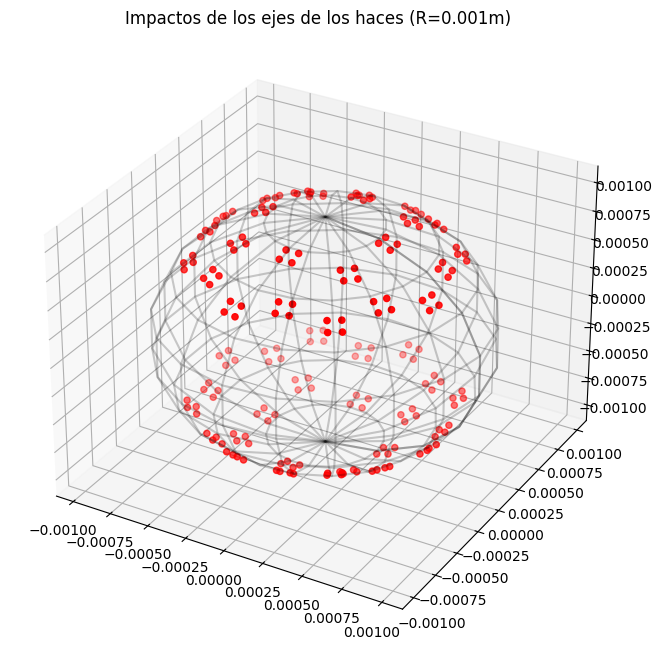

In [83]:
hits = []

# Usamos el DataFrame expandido df_beams
for i, row in df_beams_vista.iterrows():
    # 1. Reconstruimos los vectores a partir de las coordenadas x, y, z
    x = np.array([row["center_x"], row["center_y"], row["center_z"]])
    focus = np.array([row["focus_x"], row["focus_y"], row["focus_z"]])
    
    # 2. Vector director unitario
    u = focus - x
    u = u / np.linalg.norm(u)

    # 3. Ray_hit contra el BLANCO (radius = R_TARGET, no 5.0)
    # Usamos R_TARGET que definimos como 0.001
    hit = ray_hit(x, u, radius=R_TARGET)
    
    # 4. El l (distancia) es hit[2]. Si l > 0, hubo impacto.
    l_impacto = hit[2]
    
    if l_impacto > 0:
        xsph = hit[3] # Punto de impacto en el blanco
        hits.append(xsph)

# Convertir a array para graficar
if len(hits) > 0:
    hits = np.array(hits)

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(hits[:,0], hits[:,1], hits[:,2], s=20, c='red')
    
    # Añadimos una esfera visual para referencia
    u_sph, v_sph = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    x_sph = R_TARGET * np.cos(u_sph)*np.sin(v_sph)
    y_sph = R_TARGET * np.sin(u_sph)*np.sin(v_sph)
    z_sph = R_TARGET * np.cos(v_sph)
    ax.plot_wireframe(x_sph, y_sph, z_sph, color="black", alpha=0.2)

    ax.set_title(f"Impactos de los ejes de los haces (R={R_TARGET}m)")
    plt.show()
else:
    print("No se detectaron impactos en el blanco. Revisa la distancia focal o el radio.")

# Simulation of impacts for 1 window

### Creates beam sample

In [84]:
def beam_sample(beam, num_samples):
    # 1. Reconstrucción de vectores a partir de las columnas individuales (x, y, z)
    t1 = np.array([beam['t1_x'], beam['t1_y'], beam['t1_z']])
    t2 = np.array([beam['t2_x'], beam['t2_y'], beam['t2_z']])
    center = np.array([beam['center_x'], beam['center_y'], beam['center_z']])
    
    l1 = beam['l1']
    l2 = beam['l2']
    
    # 2. Definición de la distribución NORMAL (Gaussiana)
    # loc=0.0: Centrada en el eje del haz
    # scale=0.5: Desviación estándar (concentra el 95% de la energía en el área central)
    # IMPORTANTE: La lambda genera datos numéricos mediante .rvs para evitar errores de tipo
    dist_gauss = lambda n: sp.stats.norm(loc=0.0, scale=0.5).rvs(size=(n, 2))
    
    return sample_window(t1, t2, l1=l1, l2=l2, center=center, num_points=num_samples, dist=dist_gauss)

### Creates hit of beam on sphere

In [85]:
def beam_hit(beam, num_samples, radius, center_target=np.array([0.0, 0.0, 0.0])):
    # 1. Generar puntos en la ventana (llama a la función que usa la distribución normal)
    xs = beam_sample(beam, num_samples)
    
    # 2. Reconstruir el vector del foco y calcular las direcciones de propagación (us)
    # Se extraen las componentes x, y, z de la fila del DataFrame
    focus = np.array([beam['focus_x'], beam['focus_y'], beam['focus_z']])
    us = focus - xs
    
    # Normalización de los vectores directores para que sean unitarios
    us = us / np.linalg.norm(us, axis=1)[:, None]

    # 3. Trazado de rayos (Ray-tracing)
    # Se ejecuta la intersección para cada par origen-dirección generado
    data = [ray_hit(xi, ui, radius=radius, center=center_target) for xi, ui in zip(xs, us)]
    
    # 4. Creación del DataFrame de resultados con las columnas de impacto
    df = pd.DataFrame(data, columns=['x', 'u', 'l', 'xsph', 'cs', 'sph', 'n'])

    # 5. Filtrar impactos efectivos
    # Solo conservamos los rayos que realmente tocaron la esfera (l > 0)
    df = df[df['l'] > 0].copy()

    # 6. Asignación de metadatos para identificar el origen del haz
    df['port'] = beam['port']
    df['subwindow'] = beam['subwindow']

    return df

### Simulation parameters

In [86]:
impacts_1window = beam_hit(df_beams_vista.iloc[0], num_samples=10000, radius=R_TARGET, center_target=np.array([0.0, 0.0, 0.0]))

In [87]:
print(f"Impactos efectivos: {len(impacts_1window)} de 10000 rayos lanzados.")

Impactos efectivos: 9763 de 10000 rayos lanzados.


### Impacts data

In [88]:
impacts_1window.head()

,x,u,l,xsph,cs,sph,n,port,subwindow
0,"[1.8583669636268594, 0.22036735047714043, 4.64...","[-0.3711065782370494, -0.043992598244535615, -...",5.006065,"[0.0005831727137681764, 0.000137527747766375, ...",-0.965085,"[0.0010000000027432735, 0.6424635998413488, 3....","[0.5831727121683741, 0.13752774738909876, 0.80...",NP1J1,0
1,"[1.8965056460755532, 0.08011393914278152, 4.62...","[-0.3790855276647911, -0.01612879693511604, -0...",5.001061,"[0.0006756599549657683, -0.0005471640599794547...",-0.704422,"[0.0009999999981015692, 1.0540431961383996, 2....","[0.675659956248462, -0.5471640610182078, 0.494...",NP1J1,0
2,"[1.942498059806975, 0.2160122052842454, 4.6075...","[-0.3879899428916959, -0.04314453943045491, -0...",5.004239,"[0.0009037001809337752, 0.00010662334441133292...",-0.737001,"[0.0010000000035595156, 1.1432079308040202, 3....","[0.9037001777170404, 0.10662334403180547, 0.41...",NP1J1,0
3,"[1.714067051057786, 0.25220516504293466, 4.706...","[-0.3418369538054436, -0.05023567775576015, -0...",5.014799,"[-0.00017641757720787687, 0.000283359847241593...",-0.838524,"[0.0010000000014859782, 0.3403216371476641, 5....","[-0.17641757694572419, 0.2833598468205267, 0.9...",NP1J1,0
4,"[1.8908427052104768, 0.2984275722445691, 4.630...","[-0.377328523484096, -0.05947318429433004, -0....",5.009366,"[0.0006661279821928989, 0.0005046405554097744,...",-0.788907,"[0.001000000001881592, 0.9893997223914441, 3.7...","[0.6661279809395179, 0.5046405544602468, 0.549...",NP1J1,0


### Impacts of data organized

In [89]:
def expandir_impactos(df_impacts):
    # 1. Copiamos el DataFrame original para no perder datos
    df = df_impacts.copy()

    # 2. Función interna para desglosar vectores [x, y, z] o [r, theta, phi]
    def expandir_col(df_in, col_name, nombres_xyz):
        temp = pd.DataFrame(df_in[col_name].tolist(), index=df_in.index)
        temp.columns = nombres_xyz
        return temp

    # 3. Expandimos las columnas vectoriales clave
    # 'xsph' -> Punto de impacto (x, y, z)
    df_xsph = expandir_col(df, 'xsph', ['xsph_x', 'xsph_y', 'xsph_z'])
    
    # 'n' -> Normal en el punto de impacto (x, y, z)
    df_n = expandir_col(df, 'n', ['n_x', 'n_y', 'n_z'])
    
    # 'sph' -> Coordenadas esféricas del impacto (r, theta, phi)
    df_sph = expandir_col(df, 'sph', ['r', 'theta', 'phi'])
    
    # 'u' -> Dirección del rayo
    df_u = expandir_col(df, 'u', ['u_x', 'u_y', 'u_z'])

    # 4. Concatenamos todo en el orden que pediste (port y subwindow primero)
    # Seleccionamos las columnas escalares que ya existen
    cols_meta = ['port', 'subwindow', 'l', 'cs']
    
    df_final = pd.concat([
        df[cols_meta],
        df_xsph,
        df_n,
        df_sph,
        df_u
    ], axis=1)

    return df_final

# --- Ejecución ---
impact_1window_vista= expandir_impactos(impacts_1window)

# Mostramos el resultado
impact_1window_vista.head(10)

,port,subwindow,l,cs,xsph_x,xsph_y,xsph_z,n_x,n_y,n_z,r,theta,phi,u_x,u_y,u_z
0,NP1J1,0,5.006065,-0.965085,0.000583,0.000138,0.000801,0.583173,0.137528,0.800622,0.001,0.642464,3.373188,-0.371107,-0.043993,-0.927548
1,NP1J1,0,5.001061,-0.704422,0.000676,-0.000547,0.000494,0.675660,-0.547164,0.494060,0.001,1.054043,2.460892,-0.379086,-0.016129,-0.925221
2,NP1J1,0,5.004239,-0.737001,0.000904,0.000107,0.000415,0.903700,0.106623,0.414678,0.001,1.143208,3.259035,-0.387990,-0.043145,-0.920653
3,NP1J1,0,5.014799,-0.838524,-0.000176,0.000283,0.000943,-0.176418,0.283360,0.942647,0.001,0.340322,5.269255,-0.341837,-0.050236,-0.938416
4,NP1J1,0,5.009366,-0.788907,0.000666,0.000505,0.000549,0.666128,0.504641,0.549192,0.001,0.989400,3.789923,-0.377329,-0.059473,-0.924168
5,NP1J1,0,5.009605,-0.978665,0.000254,0.000226,0.000940,0.254157,0.226344,0.940305,0.001,0.347272,3.869173,-0.357424,-0.047603,-0.932728
6,NP1J1,0,5.011745,-0.937161,0.000153,0.000345,0.000926,0.153270,0.344700,0.926116,0.001,0.386813,4.293995,-0.353921,-0.052540,-0.933799
7,NP1J1,0,5.003898,-0.930299,0.000421,-0.000334,0.000843,0.421285,-0.333874,0.843236,0.001,0.567521,2.471434,-0.365017,-0.024723,-0.930672
8,NP1J1,0,5.009754,-0.869007,0.000546,0.000476,0.000689,0.546346,0.476152,0.689046,0.001,0.810624,3.858449,-0.371116,-0.058099,-0.926767
9,NP1J1,0,5.004896,-0.976956,0.000549,-0.000034,0.000835,0.549378,-0.033654,0.834896,0.001,0.582853,3.080411,-0.369535,-0.036963,-0.928481


### Plots impacts of simulation of 1 window in the sphere

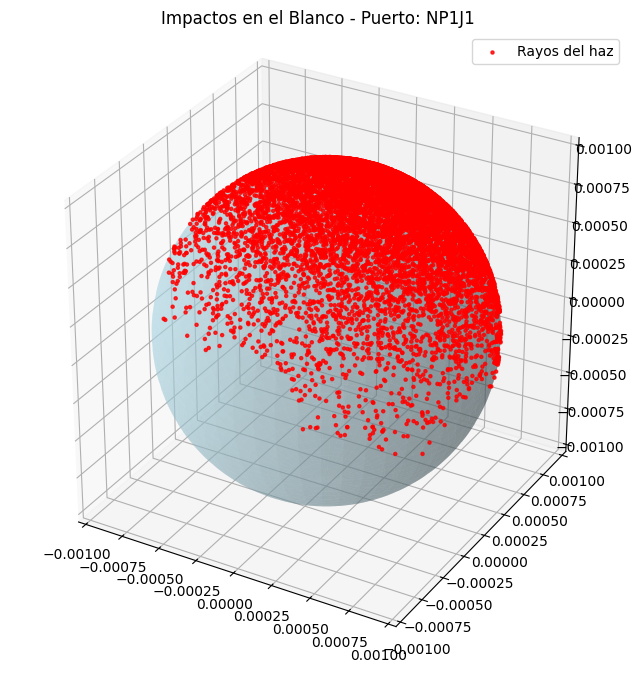

In [90]:
def plot_impacts_on_sphere_colored(impact_df_final, sphere_radius=R_TARGET):
    # 1. Crear la figura y el eje 3D
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 2. Dibujar la esfera COLOREADA (superficie sólida)
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x_sphere = sphere_radius * np.outer(np.cos(u), np.sin(v))
    y_sphere = sphere_radius * np.outer(np.sin(u), np.sin(v))
    z_sphere = sphere_radius * np.outer(np.ones_like(u), np.cos(v))
    
    # Usamos plot_surface con un color sólido y transparencia
    ax.plot_surface(x_sphere, y_sphere, z_sphere, 
                    color='lightblue', 
                    alpha=0.4,       # Transparencia para ver los puntos de detrás
                    linewidth=0,     # Sin líneas de malla para que sea suave
                    antialiased=True)

    # 3. Dibujar los puntos de impacto
    xs = impact_df_final['xsph_x']
    ys = impact_df_final['xsph_y']
    zs = impact_df_final['xsph_z']
    
    # Graficamos los puntos en rojo
    ax.scatter(xs, ys, zs, color='red', s=5, alpha=0.8, label='Rayos del haz')

    # 4. Configuración estética
    puerto = impact_df_final['port'].iloc[0] if not impact_df_final.empty else "S/N"
    ax.set_title(f"Impactos en el Blanco - Puerto: {puerto}")
    
    # Ajustar límites para que la esfera no se vea cortada
    limit = sphere_radius * 1.05
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    
    # Aspecto 1:1:1 para que sea una esfera y no un huevo
    ax.set_box_aspect([1, 1, 1])
    
    plt.legend()
    plt.show()

# --- Ejecución ---
plot_impacts_on_sphere_colored(impact_1window_vista, sphere_radius=R_TARGET)

### Pyvista plotter of the impacts in one subwindow

In [91]:
def plot_impacts_pyvista(impact_df_final, sphere_radius=R_TARGET):
    
    # ============================
    # 2. Extraer puntos de impacto
    # ============================
    xsph_array = impact_df_final[['xsph_x', 'xsph_y', 'xsph_z']].values
    ls_array = impact_df_final['l'].values

    # ============================
    # 3. Crear nube de puntos
    # ============================
    point_cloud = pv.PolyData(xsph_array)
    point_cloud["Distancia del rayo (l)"] = ls_array

    # ============================
    # 4. Crear esfera del blanco
    # ============================
    sphere = pv.Sphere(radius=sphere_radius, center=(0, 0, 0))

    # ============================
    # 5. Visualización
    # ============================
    plotter = pv.Plotter()
    plotter.add_mesh(sphere, color="lightblue", opacity=0.3)

    plotter.add_points(
        point_cloud,
        scalars="Distancia del rayo (l)",
        render_points_as_spheres=True,
        point_size=12,
        cmap="viridis"
    )

    plotter.show()

In [92]:
plot_impacts_pyvista(impact_1window_vista, sphere_radius=R_TARGET)


Widget(value='<iframe src="http://localhost:52059/index.html?ui=P_0x1f24ebbe210_11&reconnect=auto" class="pyvi…

# Simulation of hits from windows chosen by probability

### Simulation of impacts 

In [93]:
def simular_impactos(
    num_beams_to_sample,
    num_samples_per_beam,
    target_radius,
    target_center
 ):
    # 1. USAR EL DATAFRAME EXPANDIDO
    # Usamos df_beams_vista que ya tiene 't1_x', 'focus_x', etc.
    beam_df = df_beams_vista.copy() 

    # 2. Probabilidades según energía
    ps = np.array(beam_df['energy'], dtype=float)
    ps /= np.sum(ps)

    # 3. Selección aleatoria de haces (Monte Carlo)
    list_beams = np.arange(len(beam_df))
    selected_indices = np.random.choice(
        list_beams,
        size=num_beams_to_sample,
        p=ps
    )

    # 4. Simulación de impactos
    impact_list = []
    for i in selected_indices:
        # Extraemos la fila del haz seleccionado
        beam_row = beam_df.iloc[i]
        
        # Llamamos a beam_hit (que a su vez llama a beam_sample)
        # IMPORTANTE: center_target es el argumento de la función de trazado
        res = beam_hit(
            beam_row,
            num_samples_per_beam,
            radius=target_radius,
            center_target=target_center
        )
        
        if not res.empty:
            # Los metadatos ya deberían venir de beam_hit, pero aseguramos:
            res['port'] = beam_row['port']
            res['subwindow'] = beam_row['subwindow']
            impact_list.append(res)

    if not impact_list:
        print("Aviso: Ningún rayo impactó en el blanco.")
        return pd.DataFrame()

    # 5. Concatenar todos los DataFrames de impactos
    impact_df = pd.concat(impact_list, ignore_index=True)

    return impact_df


### Simulation parameters

In [94]:

# --- Ejecución ---
impactos_totales = simular_impactos(
    num_beams_to_sample=100,
    num_samples_per_beam=1000, 
    target_radius=R_TARGET,
    target_center=np.array([0.0, 0.0, 0.0])
)

print(f"Simulación masiva completada.")
print(f"Total de impactos registrados: {len(impactos_totales)}")

Simulación masiva completada.
Total de impactos registrados: 97639


### Information of impacts in dataframe

In [95]:
def impact_df_vista(df_in):
    """
    Función auxiliar para desglosar vectores en el DataFrame de impactos.
    """
    df = df_in.copy()
    
    # Función para expandir columnas vectoriales de forma eficiente
    def expand(df_target, col_name, names):
        if col_name in df_target.columns:
            temp = pd.DataFrame(df_target[col_name].tolist(), index=df_target.index)
            temp.columns = names
            return temp
        return pd.DataFrame()

    # Expandimos los vectores clave
    df_x = expand(df, 'x', ['x_x', 'x_y', 'x_z'])
    df_u = expand(df, 'u', ['u_x', 'u_y', 'u_z'])
    df_xsph = expand(df, 'xsph', ['xsph_x', 'xsph_y', 'xsph_z'])
    df_n = expand(df, 'n', ['n_x', 'n_y', 'n_z'])
    
    # Expandimos coordenadas esféricas (sph: r, theta, phi)
    df_sph = expand(df, 'sph', ['r', 'theta', 'phi'])

    # Concatenamos todo lo expandido con el original
    return pd.concat([df.drop(columns=['x', 'u', 'xsph', 'n', 'sph'], errors='ignore'), 
                      df_x, df_u, df_xsph, df_n, df_sph], axis=1)

def preparar_dataframe_impactos(impact_df):
    # 1. Expandir vectores y añadir coordenadas esféricas
    impact_df = impact_df_vista(impact_df)

    # 2. Asegurar columnas port y subwindow (evitar KeyErrors)
    if 'port' not in impact_df.columns: 
        impact_df['port'] = 'desconocido'
    if 'subwindow' not in impact_df.columns:
        impact_df['subwindow'] = 'desconocido'

    # 3. Seleccionar columnas relevantes siguiendo tu esquema
    cols = [
        'port', 'subwindow', 'l', 'cs', 'theta', 'phi',
        'x_x', 'x_y', 'x_z',
        'u_x', 'u_y', 'u_z',
        'xsph_x', 'xsph_y', 'xsph_z',
        'n_x', 'n_y', 'n_z'
    ]
    available_cols = [c for c in cols if c in impact_df.columns]

    # 4. Redondear y devolver DataFrame final
    # Usamos copy() para evitar el SettingWithCopyWarning
    formatted_df = impact_df[available_cols].copy()
    formatted_df = formatted_df.round(4)

    print(f"Impactos válidos encontrados: {len(formatted_df)}")
    return formatted_df

# --- Ejecución ---
df_impactos = preparar_dataframe_impactos(impactos_totales)
df_impactos

Impactos válidos encontrados: 97639


,port,subwindow,l,cs,theta,phi,x_x,x_y,x_z,u_x,u_y,u_z,xsph_x,xsph_y,xsph_z,n_x,n_y,n_z
0,SP2J2,0,5.0150,-0.8372,2.0129,5.8681,-2.1365,1.7670,-4.1799,0.4259,-0.3523,0.8334,-0.0008,0.0004,-0.0004,-0.8271,0.3645,-0.4279
1,SP2J2,0,5.0063,-0.9413,2.8337,6.1989,-2.0151,1.6862,-4.2625,0.4025,-0.3368,0.8512,-0.0003,0.0000,-0.0010,-0.3020,0.0255,-0.9530
2,SP2J2,0,5.0049,-0.9559,2.8860,5.6523,-1.9931,1.7102,-4.2616,0.3982,-0.3417,0.8513,-0.0002,0.0001,-0.0010,-0.2042,0.1492,-0.9675
3,SP2J2,0,5.0092,-0.6860,1.8902,4.9009,-2.0125,1.8949,-4.1783,0.4017,-0.3781,0.8341,-0.0002,0.0009,-0.0003,-0.1780,0.9326,-0.3140
4,SP2J2,0,5.0058,-0.9735,2.4983,5.1698,-2.0045,1.7893,-4.2247,0.4004,-0.3573,0.8438,-0.0003,0.0005,-0.0008,-0.2649,0.5382,-0.8001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97634,SP4J6,1,5.0067,-0.9987,2.2140,1.3891,-0.9584,-3.8477,-3.0584,0.1914,0.7684,0.6107,-0.0001,-0.0008,-0.0006,-0.1446,-0.7870,-0.5998
97635,SP4J6,1,5.0021,-0.7340,2.2297,2.3207,-0.8263,-3.8445,-3.0929,0.1653,0.7685,0.6182,0.0005,-0.0006,-0.0006,0.5389,-0.5786,-0.6122
97636,SP4J6,1,5.0073,-0.9968,2.2625,1.2257,-0.9825,-3.8357,-3.0668,0.1962,0.7659,0.6123,-0.0003,-0.0007,-0.0006,-0.2605,-0.7248,-0.6378
97637,SP4J6,1,5.0043,-0.8919,2.7152,1.2551,-0.9590,-3.7820,-3.1350,0.1916,0.7557,0.6263,-0.0001,-0.0004,-0.0009,-0.1284,-0.3932,-0.9104


### Pyvista plot

In [96]:
def plot_impactos_pyvista_alta_densidad(impact_df, sphere_radius=R_TARGET):
    # 1. Extraer puntos de impacto
    xsph_array = impact_df[['xsph_x', 'xsph_y', 'xsph_z']].values
    ls_array = impact_df['l'].values

    # 2. Crear nube de puntos
    point_cloud = pv.PolyData(xsph_array)
    point_cloud["Distancia del rayo (l)"] = ls_array

    # 3. Crear esfera del blanco
    sphere = pv.Sphere(radius=sphere_radius, center=(0, 0, 0), theta_resolution=100, phi_resolution=100)

    # 4. Visualización
    plotter = pv.Plotter()
    
    # Esfera de fondo
    plotter.add_mesh(sphere, color="lightblue", opacity=0.3)

    # Añadimos los 48,000 impactos
    # Quitamos 'depth_mapping' y 'lighting' que daban problemas
    plotter.add_mesh(
        point_cloud,
        scalars="Distancia del rayo (l)",
        render_points_as_spheres=True,
        point_size=5.0,        # <--- Tamaño intermedio para que se vean todos sin solaparse demasiado
        cmap="viridis",
        scalar_bar_args={'title': "Distancia l (m)"},
        style='points'         # <--- Esto es lo que asegura que se vean como puntos individuales
    )

    plotter.show()

# --- Ejecución ---
plot_impactos_pyvista_alta_densidad(df_impactos, sphere_radius=R_TARGET)

Widget(value='<iframe src="http://localhost:52059/index.html?ui=P_0x1f247d36010_12&reconnect=auto" class="pyvi…

In [97]:
## Exportar a hdf 

#!pip install tables

#beam_df_vista.to_hdf("beam", key='beams', mode='a', index=False)
#impact_df.to_hdf("impact", key='hits', mode='a', index=False)

## Histogram of impacts in a 1m radius sphere 

### Divides the sphere in sectors

In [98]:
class SphereSectors():
    def __init__(self, num_theta, num_phi):
      # mesh in theta-phi
      self.theta_edges = np.linspace(0, np.pi, num_theta + 1)  # incluye polos
      self.phi_edges = np.linspace(0, 2 * np.pi, num_phi + 1)  # incluye cierre

      # coordinates of the spherical sector center
      self.theta = 0.5 * (self.theta_edges[:-1] + self.theta_edges[1:])
      self.phi = 0.5 * (self.phi_edges[:-1] + self.phi_edges[1:])

      self.mtheta, self.mphi = np.meshgrid(self.theta, self.phi, indexing='ij')       

      return

sectors = SphereSectors( num_theta = 50, num_phi = 50)


### Representation of the mesh

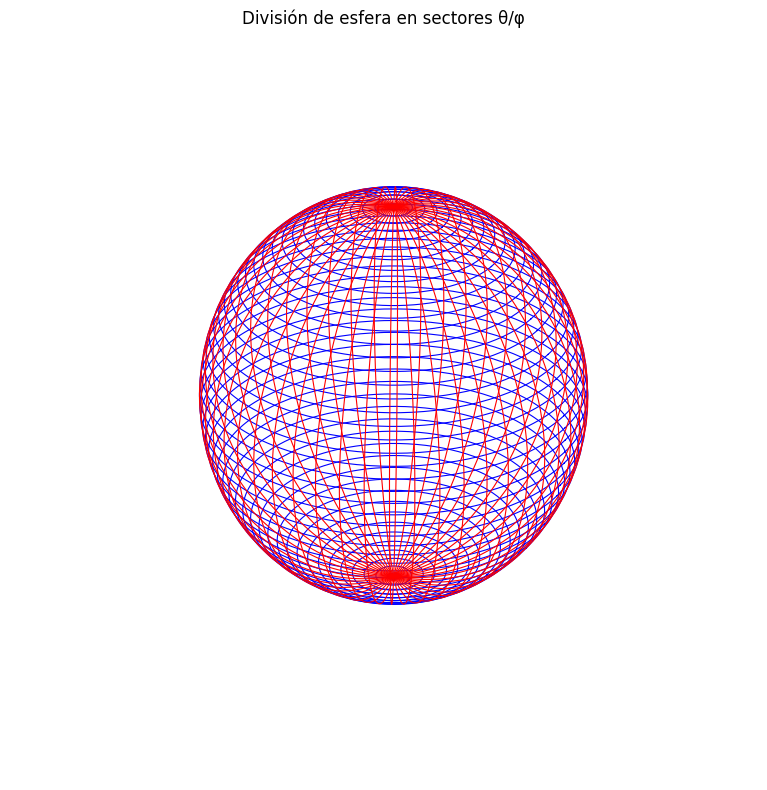

In [99]:
# Parámetros
radius = R_TARGET

# Crear figura 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujar líneas horizontales (theta)
phi = np.linspace(0, 2 * np.pi, 200)
for theta in sectors.theta:
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    ax.plot(x, y, z, color='blue', linewidth=0.8)

# Dibujar líneas verticales (phi)
theta = np.linspace(0, np.pi, 200)
for phi in sectors.phi:
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    ax.plot(x, y, z, color='red', linewidth=0.8)

# Estética
ax.set_box_aspect([1, 1, 1])
ax.set_title("División de esfera en sectores θ/φ")
ax.set_axis_off()
plt.tight_layout()
plt.show()


### Function to calculate the area of sectors of the mesh

In [100]:
def spherical_sector_area( theta1, theta2, phi1, phi2, radius=1., ):
    area_anillo = 2 * np.pi * radius**2 * np.abs(np.cos(theta1) - np.cos(theta2))
    delta_phi = np.abs(phi2 - phi1)
    area_sector = (delta_phi / (2 * np.pi)) * area_anillo
    return area_sector

sectors.area = spherical_sector_area( sectors.theta_edges[:-1][:,None], sectors.theta_edges[1:][:,None], sectors.phi_edges[:-1][None,:], sectors.phi_edges[1:][None,:], radius=1., )

assert np.isclose( np.sum( sectors.area ), 4.*np.pi, atol=1e-4 ), "El área total calculada no coincide con el área de la esfera."


### Plots the centers of each sector in the sphere mesh

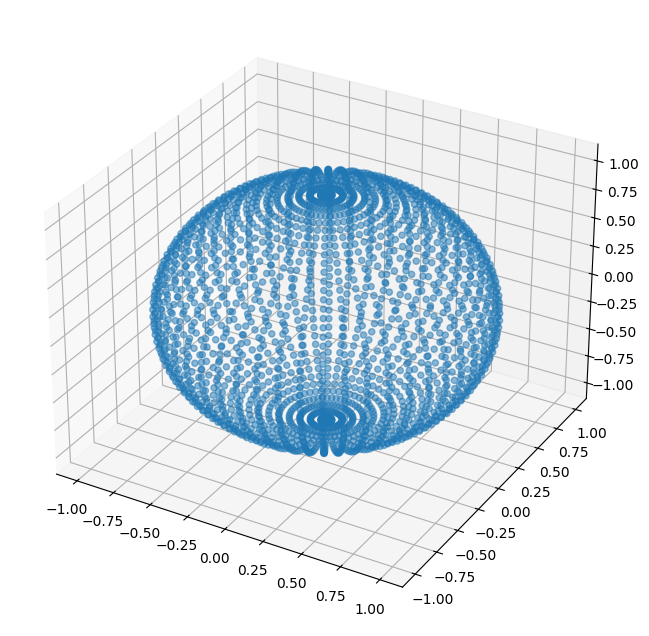

In [101]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(111, projection='3d')

xs, ys, zs = sph_to_cart(1.0, sectors.mtheta, sectors.mphi)
ax.scatter( xs, ys, zs, alpha=0.5)

## Creates energy histogram in sphere

In [102]:
def hist(hits, sectors):
    # Histograma 2D con pesos
    hs_raw, _, _ = np.histogram2d(
        hits['theta'],
        hits['phi'],
        bins=[sectors.theta_edges, sectors.phi_edges],
        weights=np.abs(hits['cs'])
    )

    # Densidad por unidad de área
    hs = hs_raw / sectors.area

    # Validación de conservación
    assert np.isclose(
        np.sum(hs * sectors.area),
        np.sum(np.abs(hits['cs'])),
        atol=1e-4
    ), "La suma ponderada no coincide con la suma original de |cs|."

    # Normalización para visualización
    hs_norm = (hs - np.min(hs)) / (np.max(hs) - np.min(hs))

    # DataFrame final
    df_hist = pd.DataFrame({
        'theta': sectors.mtheta.ravel(),
        'phi': sectors.mphi.ravel(),
        'hs_raw': hs_raw.ravel(),
        'hs_density': hs.ravel(),
        'hs_norm': hs_norm.ravel()
    })

    return df_hist


In [103]:
hits = df_impactos[df_impactos['cs'] < 0]   # impactos físicos


In [104]:
df_hist = hist(hits, sectors)

hs = df_hist['hs_density'].values

### Histogram graphic

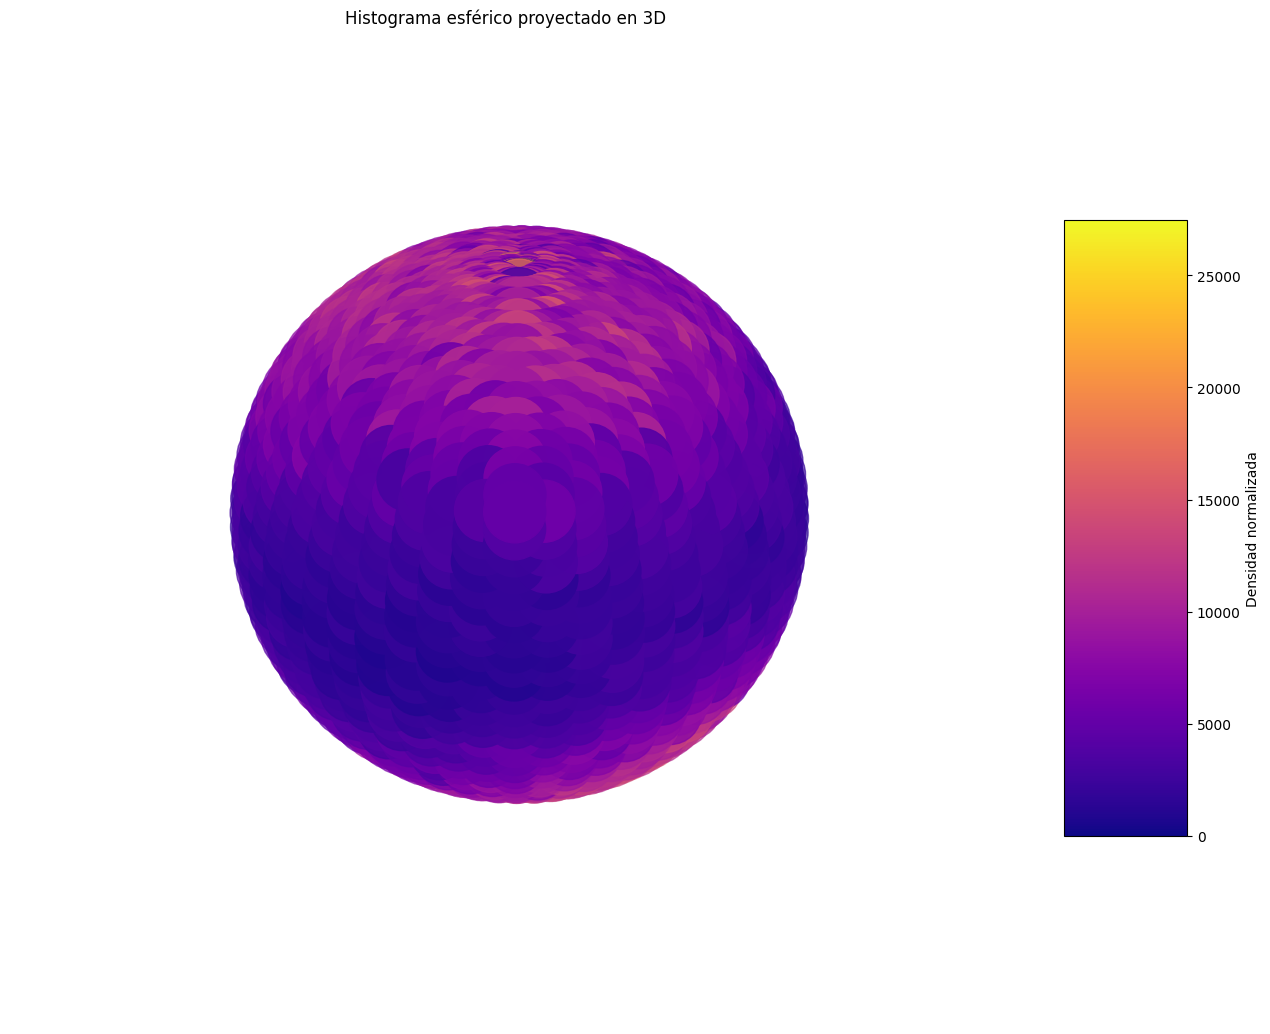

In [105]:
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')

# Convertir centros de sector a coordenadas cartesianas
xs, ys, zs = sph_to_cart(1.0, sectors.mtheta, sectors.mphi)

# Aplanar para scatter
X = xs.ravel()
Y = ys.ravel()
Z = zs.ravel()
C = hs.ravel()   # hs debe ser el histograma normalizado o densidad

# Plot
p = ax.scatter(X, Y, Z, c=C, cmap='plasma', s=2000)

# Colorbar
cb = fig.colorbar(p, ax=ax, shrink=0.5, aspect=5)
cb.set_label("Densidad normalizada")

ax.set_box_aspect([1, 1, 1])
ax.set_title("Histograma esférico proyectado en 3D")
ax.set_axis_off()

plt.show()


### Pyvista histogram graphic

In [106]:
def plot_histograma_esferico_pyvista(sectors, hs, radius=0.005, cmap="plasma"):
    
    # Convertir centros de sector a coordenadas cartesianas
    xs, ys, zs = sph_to_cart(radius, sectors.mtheta, sectors.mphi)

    # Aplanar para scatter
    X = xs.ravel()
    Y = ys.ravel()
    Z = zs.ravel()
    C = hs.ravel()

    # Crear nube de puntos
    point_cloud = pv.PolyData(np.column_stack([X, Y, Z]))
    point_cloud["densidad"] = C

    # Crear esfera del blanco
    sphere = pv.Sphere(radius=radius, center=(0, 0, 0))

    # Visualización
    pv.set_jupyter_backend('trame')
    plotter = pv.Plotter()

    # Esfera semitransparente
    plotter.add_mesh(sphere, color="lightblue", opacity=0.25)

    # Puntos coloreados por densidad
    plotter.add_points(
        point_cloud,
        scalars="densidad",
        render_points_as_spheres=True,
        point_size=20,
        cmap=cmap
    )

    plotter.add_scalar_bar(title="Densidad angular normalizada")
    plotter.show()

plot_histograma_esferico_pyvista(sectors, hs, radius=0.005, cmap="plasma")

Widget(value='<iframe src="http://localhost:52059/index.html?ui=P_0x1f24c766210_13&reconnect=auto" class="pyvi…

## Import to rwhist file

In [107]:
import rwhist
rwhist.write(df_hist, filename="histograma_muestreo.h5")
